In [1]:
!pwd

/home/ashiksufaid/aqi_monitoring_dashboard-/latest


datetime_from: 2026-04-02T09:01:00Z

Fetching pm10 (ID=1)
pm10 | Page 1 → 1000
pm10 | Page 2 → 1000
pm10 | Page 3 → 1000
pm10 | Page 4 → 898
Error 404: {"detail":"Parameter not found"}
pm10 → Filtered: 753

Fetching pm25 (ID=2)
pm25 | Page 1 → 1000
pm25 | Page 2 → 1000
pm25 | Page 3 → 1000
pm25 | Page 4 → 1000
pm25 | Page 5 → 1000
pm25 | Page 6 → 1000
pm25 | Page 7 → 1000
pm25 | Page 8 → 1000
pm25 | Page 9 → 1000
pm25 | Page 10 → 703
Error 404: {"detail":"Parameter not found"}
pm25 → Filtered: 751

Fetching o3 (ID=3)
o3 | Page 1 → 1000
o3 | Page 2 → 1000
o3 | Page 3 → 36
Error 404: {"detail":"Parameter not found"}
o3 → Filtered: 765


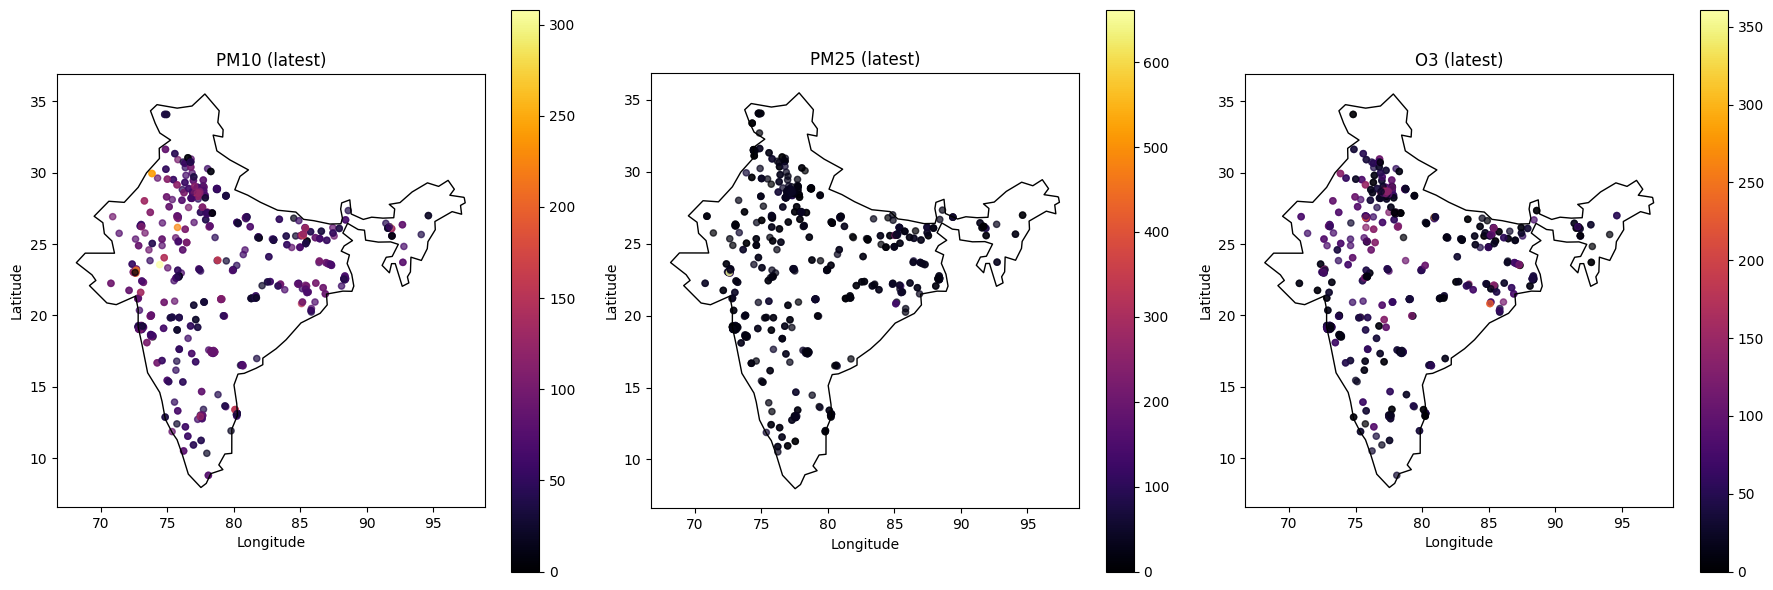

In [8]:
# -----------------------------
# Imports
# -----------------------------
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from latest_india import get_latest_india
# -----------------------------
# Call your function
# -----------------------------
dfs = get_latest_india(nhrs=3, save=False)

# -----------------------------
# Load India shapefile
# -----------------------------
shp_path = "ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shp_path)
india = world[world["ADMIN"] == "India"]

# -----------------------------
# Function to convert df → GeoDataFrame
# -----------------------------
def df_to_gdf(df):
    df = df[df["value"] >= 0]
    geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

params = ["pm10", "pm25", "o3"]

for i, pname in enumerate(params):
    df = dfs[pname]
    
    if df.empty:
        print(f"{pname} has no data")
        continue
    
    gdf = df_to_gdf(df)
    
    ax = axes[i]
    
    # Plot India boundary
    india.boundary.plot(ax=ax, linewidth=1, color="black")
    
    # Plot points
    gdf.plot(
        ax=ax,
        column="value",
        cmap="inferno",
        legend=True,
        markersize=20,
        alpha=0.7
    )
    
    ax.set_title(f"{pname.upper()} (latest)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

datetime_from: 2026-04-02T09:04:00Z

Fetching pm10 (ID=1)
pm10 | Page 1 → 1000
pm10 | Page 2 → 1000
pm10 | Page 3 → 1000
pm10 | Page 4 → 898
Error 404: {"detail":"Parameter not found"}
pm10 → Filtered: 748

Fetching pm25 (ID=2)
pm25 | Page 1 → 1000
pm25 | Page 2 → 1000
pm25 | Page 3 → 1000
pm25 | Page 4 → 1000
pm25 | Page 5 → 1000
pm25 | Page 6 → 1000
pm25 | Page 7 → 1000
pm25 | Page 8 → 1000
pm25 | Page 9 → 1000
pm25 | Page 10 → 703
Error 404: {"detail":"Parameter not found"}
pm25 → Filtered: 741

Fetching o3 (ID=3)
o3 | Page 1 → 1000
o3 | Page 2 → 1000
o3 | Page 3 → 36
Error 404: {"detail":"Parameter not found"}
o3 → Filtered: 767
Interpolating pm10...
Interpolating pm25...
Interpolating o3...


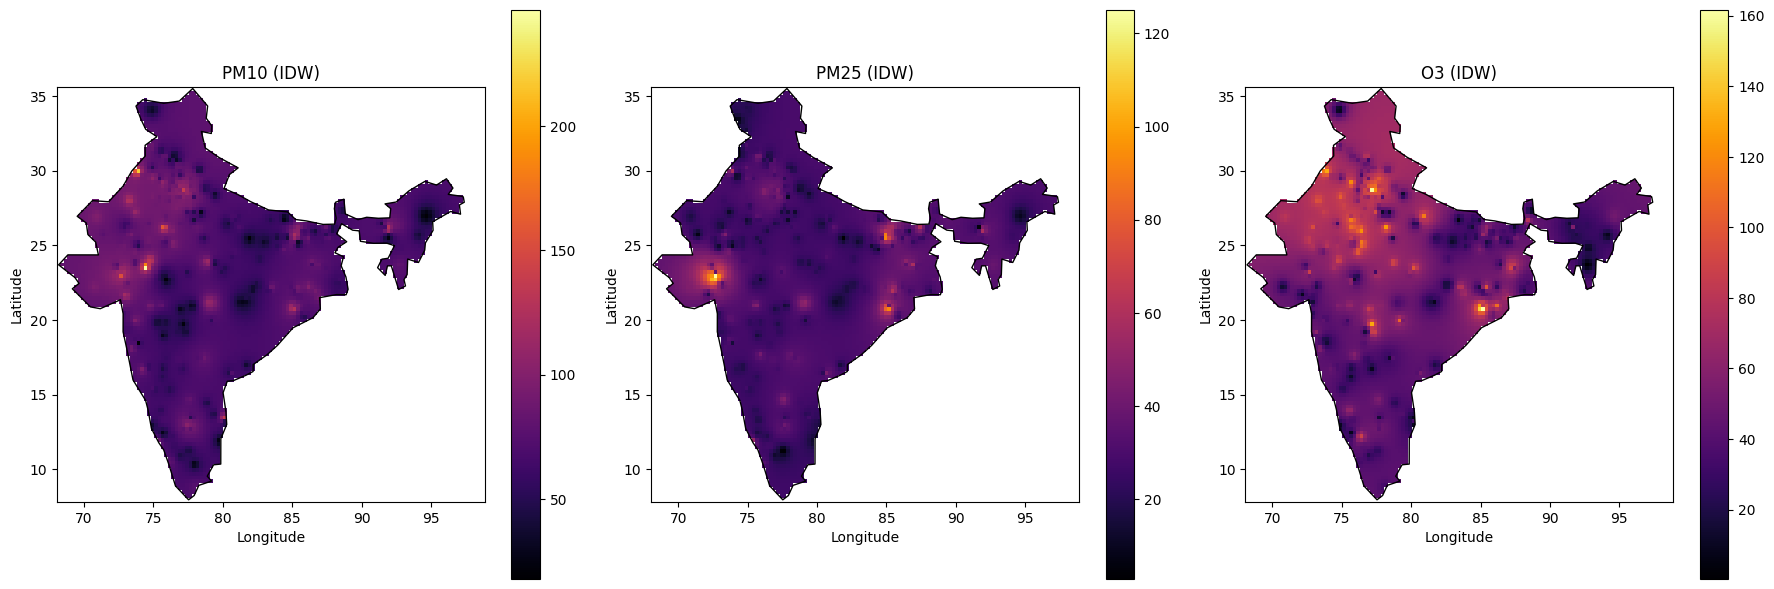

In [9]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from latest_india import get_latest_india
# -----------------------------
# Call your function
# -----------------------------
dfs = get_latest_india(nhrs=3, save=False)

# -----------------------------
# Load India shapefile
# -----------------------------
shp_path = "ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shp_path)
india = world[world["ADMIN"] == "India"]
india_geom = india.geometry.iloc[0]

# -----------------------------
# IDW function
# -----------------------------
def idw_interpolation(x, y, z, xi, yi, power=2):
    """
    x, y : station coords
    z    : values
    xi, yi : grid
    """
    zi = np.zeros_like(xi)

    for i in range(xi.shape[0]):
        for j in range(xi.shape[1]):
            dist = np.sqrt((x - xi[i, j])**2 + (y - yi[i, j])**2)

            # Avoid division by zero
            if np.any(dist == 0):
                zi[i, j] = z[dist == 0][0]
            else:
                weights = 1 / dist**power
                zi[i, j] = np.sum(weights * z) / np.sum(weights)

    return zi

# -----------------------------
# Grid over India
# -----------------------------
lon_min, lat_min, lon_max, lat_max = india.total_bounds

grid_res = 0.25   # smaller = smoother but slower
grid_lon = np.arange(lon_min, lon_max, grid_res)
grid_lat = np.arange(lat_min, lat_max, grid_res)

xi, yi = np.meshgrid(grid_lon, grid_lat)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
params = ["pm10", "pm25", "o3"]

for i, pname in enumerate(params):
    df = dfs[pname]
    df = df[df["value"] >= 0]
    ax = axes[i]

    if df.empty:
        ax.set_title(f"{pname} (no data)")
        continue

    x = df["lon"].values
    y = df["lat"].values
    z = df["value"].values

    print(f"Interpolating {pname}...")

    zi = idw_interpolation(x, y, z, xi, yi, power=2)

    # -----------------------------
    # Mask outside India
    # -----------------------------
    mask = np.array([
        india_geom.contains(Point(xi[i, j], yi[i, j]))
        for i in range(xi.shape[0])
        for j in range(xi.shape[1])
    ]).reshape(xi.shape)

    zi[~mask] = np.nan

    # -----------------------------
    # Plot heatmap
    # -----------------------------
    im = ax.pcolormesh(
        xi, yi, zi,
        shading="auto",
        cmap="inferno"
    )

    india.boundary.plot(ax=ax, color="black", linewidth=1)

    ax.set_title(f"{pname.upper()} (IDW)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

datetime_from: 2026-04-02T09:14:00Z

Fetching pm10 (ID=1)
pm10 | Page 1 → 1000
pm10 | Page 2 → 1000
pm10 | Page 3 → 1000
pm10 | Page 4 → 898
Error 404: {"detail":"Parameter not found"}
pm10 → Filtered: 773

Fetching pm25 (ID=2)
pm25 | Page 1 → 1000
pm25 | Page 2 → 1000
pm25 | Page 3 → 1000
pm25 | Page 4 → 1000
pm25 | Page 5 → 1000
pm25 | Page 6 → 1000
pm25 | Page 7 → 1000
pm25 | Page 8 → 1000
pm25 | Page 9 → 1000
pm25 | Page 10 → 703
Error 404: {"detail":"Parameter not found"}
pm25 → Filtered: 737

Fetching o3 (ID=3)
o3 | Page 1 → 1000
o3 | Page 2 → 1000
o3 | Page 3 → 36
Error 404: {"detail":"Parameter not found"}
o3 → Filtered: 767
Interpolating pm10...
Interpolating pm25...
Interpolating o3...


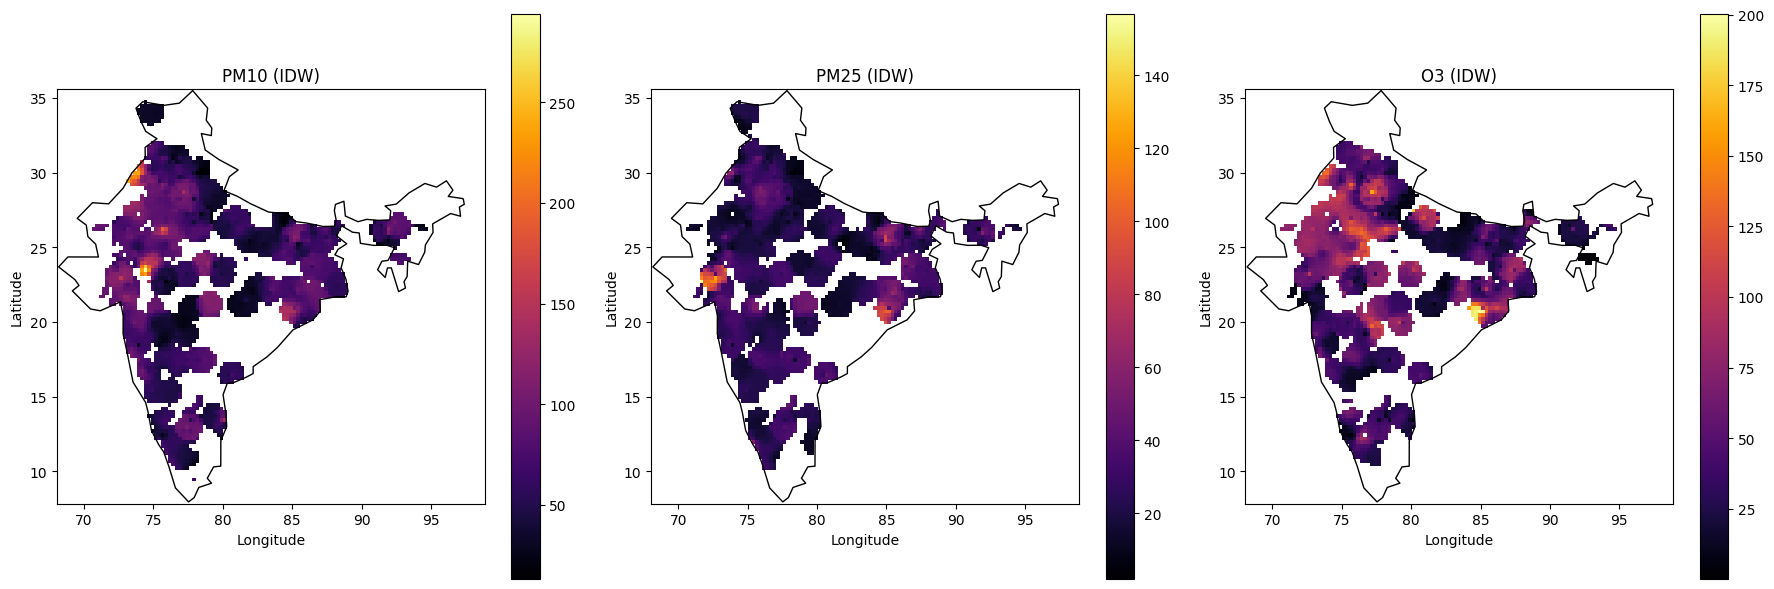

In [20]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from latest_india import get_latest_india
# -----------------------------
# Call your function
# -----------------------------
dfs = get_latest_india(nhrs=3, save=False)

# -----------------------------
# Load India shapefile
# -----------------------------
shp_path = "ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shp_path)
india = world[world["ADMIN"] == "India"]
india_geom = india.geometry.iloc[0]


# -----------------------------
# Haversine distance (km)
# -----------------------------
def haversine(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km
    
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


# -----------------------------
# Hybrid IDW
# -----------------------------
def idw_interpolation(x, y, z, xi, yi, power=2, radius=100, min_points=3):
    """
    Hybrid IDW:
    - Uses haversine distance (km)
    - Applies radius cutoff
    - Requires minimum number of stations
    """
    zi = np.full_like(xi, np.nan)

    for i in range(xi.shape[0]):
        for j in range(xi.shape[1]):
            
            dist = haversine(x, y, xi[i, j], yi[i, j])

            # Apply radius filter
            mask = dist <= radius

            # Require minimum stations
            if np.sum(mask) < min_points:
                continue

            dist_valid = dist[mask]
            z_valid = z[mask]

            # Exact match case
            if np.any(dist_valid == 0):
                zi[i, j] = z_valid[dist_valid == 0][0]
            else:
                weights = 1 / dist_valid**power
                zi[i, j] = np.sum(weights * z_valid) / np.sum(weights)

    return zi

# -----------------------------
# Grid over India
# -----------------------------
lon_min, lat_min, lon_max, lat_max = india.total_bounds

grid_res = 0.25   # smaller = smoother but slower
grid_lon = np.arange(lon_min, lon_max, grid_res)
grid_lat = np.arange(lat_min, lat_max, grid_res)

xi, yi = np.meshgrid(grid_lon, grid_lat)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
params = ["pm10", "pm25", "o3"]

for i, pname in enumerate(params):
    df = dfs[pname]
    df = df[df["value"] >= 0]
    ax = axes[i]

    if df.empty:
        ax.set_title(f"{pname} (no data)")
        continue

    x = df["lon"].values
    y = df["lat"].values
    z = df["value"].values

    print(f"Interpolating {pname}...")

    zi = idw_interpolation(
        x, y, z, xi, yi,
        power=2,
        radius=100,      # 🔥 key parameter
        min_points=3    # 🔥 hybrid constraint
    )

    # -----------------------------
    # Mask outside India
    # -----------------------------
    mask = np.array([
        india_geom.contains(Point(xi[i, j], yi[i, j]))
        for i in range(xi.shape[0])
        for j in range(xi.shape[1])
    ]).reshape(xi.shape)

    zi[~mask] = np.nan

    # -----------------------------
    # Plot heatmap
    # -----------------------------
    im = ax.pcolormesh(
        xi, yi, zi,
        shading="auto",
        cmap="inferno"
    )

    india.boundary.plot(ax=ax, color="black", linewidth=1)

    ax.set_title(f"{pname.upper()} (IDW)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(111, 117))